In [67]:
from statsmodels.stats.multitest import multipletests
from collections import defaultdict
from scipy.stats import wilcoxon
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import json
import re
import os


In [47]:
data_dir = "../data"
processed_dir = os.path.join(data_dir, "processed")


In [ ]:
def load_json(path):
	with open(path, encoding="utf-8") as f:
		return json.load(f)

def load_tests(base_dir: str):
	data = defaultdict(lambda: {
		"pre": {"code": None, "full": None},
		"post": {"code": None, "full": None},
	})

	for phase in ["Pre", "Post"]:
		phase_key = phase.lower()
		phase_dir = os.path.join(base_dir, phase)

		for file in os.listdir(phase_dir):
			if file.endswith(".json"):
				file_path = os.path.join(phase_dir, file)
				content = load_json(file_path)

				kind = "code" if "code" in file else "full"

				for user_id, user_data in content.items():
					data[user_id][phase_key][kind] = user_data

	return dict(data)


In [ ]:
def parse_likert(v: str):
	m = re.match(r"AO0?(\d)", v)
	if m:
		return int(m.group(1))

	return None

def extract_data(code: dict, full: dict):
	out = {}
	items = {}

	full_keys = list(full.keys())

	for idx, (k, v) in enumerate(code.items()):
		if k.startswith("G02Q03[SQ"):		
			m = re.search(r"\[SQ(\d+)\]", k)
			if m:
				q_id = f"Q{m.group(1)}"
				out[q_id] = parse_likert(v)
				items[q_id] = full_keys[idx]

	return items, out


In [50]:
base_dir = os.path.join(processed_dir, "CarpeDiem-11-06-2025")
tests = load_tests(base_dir)


In [ ]:
rows = []

for user_id, test in tests.items():
	pre_code = test["pre"]["code"]
	pre_full = test["pre"]["full"]
	post_code = test["post"]["code"]
	post_full = test["post"]["full"]

	if not all([pre_code, pre_full, post_code, post_full]):
		print("Skipping:", user_id)
		continue

	pre_items, pre_vals = extract_data(pre_code, pre_full)
	post_items, post_vals = extract_data(post_code, post_full)

	common_ids = set(pre_vals) & set(post_vals)

	for id in common_ids:
		rows.append({
			"user_id": user_id,
			"id": id,
			"item": pre_items[id],
			"pre": pre_vals[id],
			"post": post_vals[id]
		})

global_df = pd.DataFrame(rows)
global_df["diff"] = global_df["post"] - global_df["pre"]

print("Total users:", global_df["user_id"].nunique())
print("Total rows:", len(global_df))

display(global_df.head())
	

Total users: 32
Total rows: 640


,user_id,id,item,pre,post,diff
0,684837aae48b5a00221a37c9_uzdq,Q01,¿Cómo de peligrosas consideras las siguientes ...,3,3,0
1,684837aae48b5a00221a37c9_uzdq,Q08,¿Cómo de peligrosas consideras las siguientes ...,6,6,0
2,684837aae48b5a00221a37c9_uzdq,Q17,¿Cómo de peligrosas consideras las siguientes ...,1,3,2
3,684837aae48b5a00221a37c9_uzdq,Q12,¿Cómo de peligrosas consideras las siguientes ...,6,6,0
4,684837aae48b5a00221a37c9_uzdq,Q18,¿Cómo de peligrosas consideras las siguientes ...,2,2,0


In [ ]:
results = []

for item_id, df_item in global_df.groupby("id"):
	# Por precaución, se descarta la muestra si hay pocos participantes
	if len(df_item) < 5:
		print("Skipping:", item_id)
		continue

	pre = df_item["pre"]
	post = df_item["post"]
	# print(pre.nunique())

	# Por precaución, se filtran casos con un único valor
	if pre.nunique() < 2 and post.nunique() < 2:
		print("Skipping:", item_id)
		continue

	# Wilcoxon signed-rank test
	# https://numiqo.es/tutorial/wilcoxon-test
	# https://r-coder.com/test-wilcoxon-r/
	# Test no parámetrico que se usa cuando hay datos pareados (mismas personas en pre y post)
	# Hipótesis
	# H0: mediana(post) <= mediana(pre) -> no hay aumento en el post respecto al pre
	# H1: mediana(post) > mediana(pre) -> el post es mayor que el pre
	# Si p < 0.05, se rechaza H0, lo que indica evidencia estadística a favor de H1. Esto no demuestra que H1 sea cierta, sino que los datos son poco compatibles con H0
	stat, p = wilcoxon(post, pre, alternative="greater")

	results.append({
		"id": item_id,
		"item": df_item["item"].iloc[0],
		"n": len(df_item),
		"median_pre": pre.median(),
    	"median_post": post.median(),
    	"diff_median": post.median() - pre.median(),
		"stat": stat,
		"p": p
	})

results_df = pd.DataFrame(results)

# FDR Benjamini-Hochberg
results_df["p_adj"] = multipletests(results_df["p"], method="fdr_bh")[1]

results_df["significant"] = results_df["p_adj"] < 0.05

display(results_df)


,id,item,n,median_pre,median_post,diff_median,stat,p,p_adj,significant
0,Q01,¿Cómo de peligrosas consideras las siguientes ...,32,4.0,5.0,1.0,182.5,0.001474,0.003685,True
1,Q02,¿Cómo de peligrosas consideras las siguientes ...,32,4.0,5.0,1.0,115.5,0.006096,0.008709,True
2,Q03,¿Cómo de peligrosas consideras las siguientes ...,32,4.0,5.0,1.0,221.0,0.000705,0.002059,True
3,Q04,¿Cómo de peligrosas consideras las siguientes ...,32,5.0,5.0,0.0,141.5,0.005314,0.008175,True
4,Q05,¿Cómo de peligrosas consideras las siguientes ...,32,5.0,6.0,1.0,108.0,0.002129,0.004258,True
5,Q06,¿Cómo de peligrosas consideras las siguientes ...,32,4.0,6.0,2.0,246.0,0.000032,0.000552,True
6,Q07,¿Cómo de peligrosas consideras las siguientes ...,32,5.0,6.0,1.0,103.5,0.005235,0.008175,True
7,Q08,¿Cómo de peligrosas consideras las siguientes ...,32,5.0,6.0,1.0,198.0,0.001698,0.003773,True
8,Q09,¿Cómo de peligrosas consideras las siguientes ...,32,4.0,5.0,1.0,177.0,0.000328,0.001313,True
9,Q10,¿Cómo de peligrosas consideras las siguientes ...,32,4.0,5.0,1.0,203.0,0.000076,0.000552,True


In [ ]:
item_diff_df = (
	global_df
	.groupby("id")
	# Definir cómo se reduce cada columna por grupo
	.agg(
		# Tomar el primer item
		item=("item", "first"),
		pre=("pre", "mean"),
		post=("post", "mean"),
		diff=("diff", "mean"),
	)
	.reset_index()
)

display(item_diff_df)


,id,item,pre,post,diff
0,Q01,¿Cómo de peligrosas consideras las siguientes ...,3.96875,4.68750,0.71875
1,Q02,¿Cómo de peligrosas consideras las siguientes ...,4.25000,4.87500,0.62500
2,Q03,¿Cómo de peligrosas consideras las siguientes ...,3.93750,4.71875,0.78125
3,Q04,¿Cómo de peligrosas consideras las siguientes ...,4.59375,5.09375,0.50000
4,Q05,¿Cómo de peligrosas consideras las siguientes ...,4.87500,5.37500,0.50000
5,Q06,¿Cómo de peligrosas consideras las siguientes ...,4.25000,5.18750,0.93750
6,Q07,¿Cómo de peligrosas consideras las siguientes ...,4.71875,5.21875,0.50000
7,Q08,¿Cómo de peligrosas consideras las siguientes ...,4.56250,5.37500,0.81250
8,Q09,¿Cómo de peligrosas consideras las siguientes ...,4.18750,5.00000,0.81250
9,Q10,¿Cómo de peligrosas consideras las siguientes ...,4.15625,5.03125,0.87500


In [ ]:
id_to_keyword = {
	"Q01": "public_profile",
	"Q02": "accept_strangers",
	"Q03": "public_servers",
	"Q04": "chat_with_strangers",
	"Q05": "video call_with_strangers",
	"Q06": "befriend_strangers",
	"Q07": "meet_in_person",
	"Q08": "talk_to_adults_online",
	"Q09": "face_photo",
	"Q10": "photos_of_friends",
	"Q11": "swimsuit_photo",
	"Q12": "sexuality",
	"Q13": "phone_number",
	"Q14": "full_name",
	"Q15": "age/birthday",
	"Q16": "school",
	"Q17": "country",
	"Q18": "province/state",
	"Q19": "street",
	"Q20": "home_address"
}

item_diff_df["keyword"] = item_diff_df["id"].map(id_to_keyword)

display(item_diff_df)


,id,item,pre,post,diff,keyword
0,Q01,¿Cómo de peligrosas consideras las siguientes ...,3.96875,4.68750,0.71875,public_profile
1,Q02,¿Cómo de peligrosas consideras las siguientes ...,4.25000,4.87500,0.62500,accept_strangers
2,Q03,¿Cómo de peligrosas consideras las siguientes ...,3.93750,4.71875,0.78125,public_servers
3,Q04,¿Cómo de peligrosas consideras las siguientes ...,4.59375,5.09375,0.50000,chat_with_strangers
4,Q05,¿Cómo de peligrosas consideras las siguientes ...,4.87500,5.37500,0.50000,video call_with_strangers
5,Q06,¿Cómo de peligrosas consideras las siguientes ...,4.25000,5.18750,0.93750,befriend_strangers
6,Q07,¿Cómo de peligrosas consideras las siguientes ...,4.71875,5.21875,0.50000,meet_in_person
7,Q08,¿Cómo de peligrosas consideras las siguientes ...,4.56250,5.37500,0.81250,talk_to_adults_online
8,Q09,¿Cómo de peligrosas consideras las siguientes ...,4.18750,5.00000,0.81250,face_photo
9,Q10,¿Cómo de peligrosas consideras las siguientes ...,4.15625,5.03125,0.87500,photos_of_friends


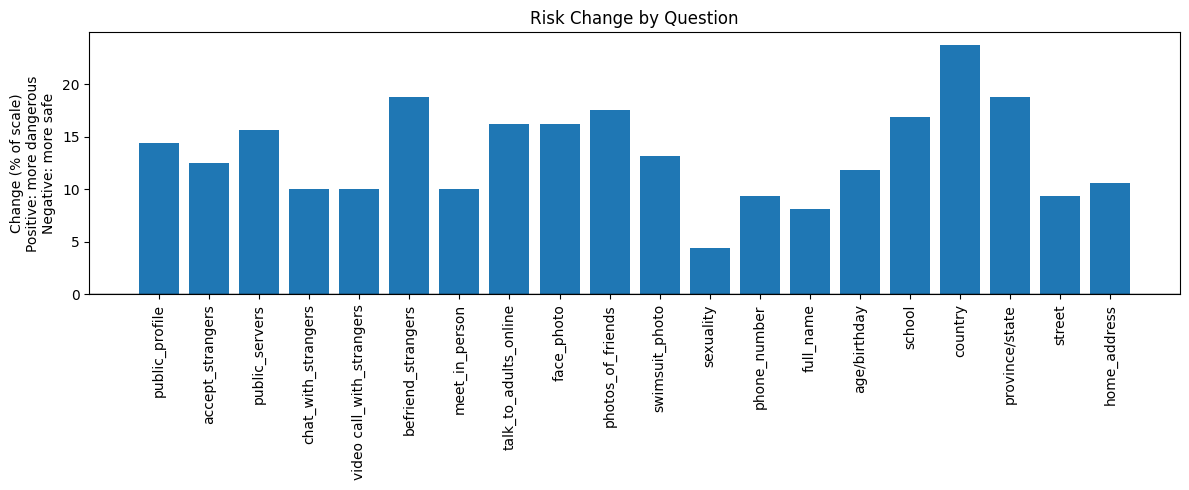

In [ ]:
plt.figure(figsize=(12, 5))

normalized_diff = (item_diff_df["diff"] / 5) * 100

plt.bar(item_diff_df["keyword"], normalized_diff)

plt.axhline(0, color="black", linewidth=1)

plt.xticks(rotation=90)
plt.ylabel("Change (% of scale)\nPositive: more dangerous\nNegative: more safe")
plt.title("Risk Change by Question")

plt.tight_layout()
plt.show()


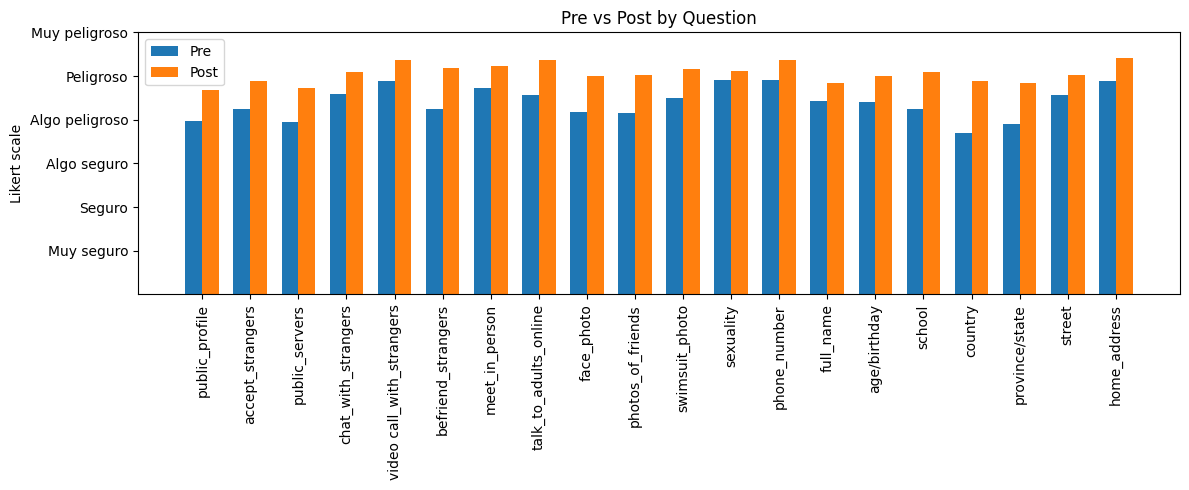

In [ ]:
likert_labels = {
	1: "Muy seguro",
	2: "Seguro",
	3: "Algo seguro",
	4: "Algo peligroso",
	5: "Peligroso",
	6: "Muy peligroso"
}

x = np.arange(len(item_diff_df))
width = 0.35

plt.figure(figsize=(12, 5))

plt.bar(x - width/2, item_diff_df["pre"], width, label="Pre")
plt.bar(x + width/2, item_diff_df["post"], width, label="Post")

plt.xticks(x, item_diff_df["keyword"], rotation=90)
plt.yticks(list(likert_labels.keys()), list(likert_labels.values()))

plt.ylabel("Likert scale")
plt.title("Pre vs Post by Question")
plt.legend()

plt.tight_layout()
plt.show()
